# Laboratorium 9 - Faktoryzacja
Jakub Fabia

## Biblioteki

In [1]:
using LinearAlgebra, DataFrames, Statistics, CSV, Polynomials, Plots

# Zadanie 1 - Porównanie inv() - / - factorize()

In [2]:
df = DataFrame(Iteration=Integer[],Method=String[],Difference=Float64[],Time=Float64[])
for i in 1:100
    ref = rand(1000)
    A = rand(1000,1000)
    b = A*ref
    invMethod = ref - inv(A)*b
    res1 = sqrt(dot(invMethod,invMethod))
    time1 = @elapsed inv(A)*b
    push!(df,(i, "inv()",res1,time1))
    
    normMethod = ref - A\b
    res2 = sqrt(dot(normMethod,normMethod))
    time2 = @elapsed A\b
    push!(df,(i, "/",res2,time2))
    
    Af = factorize(A)
    factMethod = ref - Af\b
    res3 = sqrt(dot(factMethod,factMethod))
    time3 = @elapsed factorize(A)\b
    push!(df,(i, "factorize()",res3,time3))
end


df

Row,Iteration,Method,Difference,Time
,Integer,String,Float64,Float64
1,1,inv(),1.41685e-10,0.220125
2,1,/,7.95486e-12,0.00806994
3,1,factorize(),7.95486e-12,0.0108644
4,2,inv(),3.9364e-11,0.0356409
5,2,/,2.38122e-11,0.0145125
6,2,factorize(),2.38122e-11,0.00912188
7,3,inv(),9.8447e-11,0.0327507
8,3,/,1.33061e-11,0.0119059
9,3,factorize(),1.33061e-11,0.0106537


In [3]:
plot_df = combine(
    groupby(df, :"Method"), 
    "Difference" => mean, 
    "Difference" => std, 
    "Time" => mean, 
    "Time" => std
)

Row,Method,Difference_mean,Difference_std,Time_mean,Time_std
,String,Float64,Float64,Float64,Float64
1,inv(),1.81855e-10,6.42134e-10,0.0325563,0.0192822
2,/,4.68617e-11,8.5435e-11,0.0115742,0.00361649
3,factorize(),4.68617e-11,8.5435e-11,0.0160767,0.0313553


# Zadanie 2 - Współczynniki wielomianu aproksymującego (faktoryzacja QR)

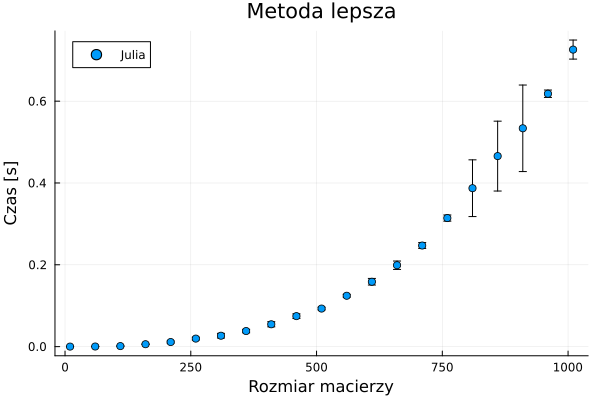

In [4]:
data = CSV.read("resultsJulia.csv", DataFrame)

res = combine(
    groupby(data, :"size"),
    "time_better" => mean, 
    "time_better" => std
)

p1 = scatter(
    res.size, 
    res.time_better_mean, 
    yerr = res.time_better_std,
    xlabel = "Rozmiar macierzy", 
    ylabel = "Czas [s]", 
    title = "Metoda lepsza", 
    label="Julia"
)

In [5]:
x_julia = res[!,1]

21-element Vector{Int64}:
   10
   60
  110
  160
  210
  260
  310
  360
  410
  460
  510
  560
  610
  660
  710
  760
  810
  860
  910
  960
 1010

In [6]:
y_julia_i = res[!, 2]

21-element Vector{Float64}:
 2.1609999999999997e-6
 0.00020819979999999998
 0.0012225799
 0.005831728100000001
 0.0111661864
 0.0195636967
 0.0265982583
 0.0380267545
 0.054549884699999995
 0.074485838
 0.09297141919999999
 0.1243202328
 0.1585778722
 0.1989926855
 0.24711582640000002
 0.3142587279
 0.3872801504
 0.4657744127
 0.5337710838
 0.6182392617000001
 0.7261642568

In [7]:
A_aprox = zeros(21,4)

21×4 Matrix{Float64}:
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0

In [8]:
A_aprox[:,1]=x_julia.^3;
A_aprox[:,2]=x_julia.^2;
A_aprox[:,3]=x_julia.^1;
A_aprox[:,4]=ones(21);
A_aprox

21×4 Matrix{Float64}:
   1000.0           100.0         10.0  1.0
 216000.0          3600.0         60.0  1.0
      1.331e6     12100.0        110.0  1.0
      4.096e6     25600.0        160.0  1.0
      9.261e6     44100.0        210.0  1.0
      1.7576e7    67600.0        260.0  1.0
      2.9791e7    96100.0        310.0  1.0
      4.6656e7   129600.0        360.0  1.0
      6.8921e7   168100.0        410.0  1.0
      9.7336e7   211600.0        460.0  1.0
      1.32651e8  260100.0        510.0  1.0
      1.75616e8  313600.0        560.0  1.0
      2.26981e8  372100.0        610.0  1.0
      2.87496e8  435600.0        660.0  1.0
      3.57911e8  504100.0        710.0  1.0
      4.38976e8  577600.0        760.0  1.0
      5.31441e8  656100.0        810.0  1.0
      6.36056e8  739600.0        860.0  1.0
      7.53571e8  828100.0        910.0  1.0
      8.84736e8  921600.0        960.0  1.0
      1.0303e9        1.0201e6  1010.0  1.0

In [9]:
A_aprox_F = factorize(A_aprox);

In [10]:
aprox_res_QR = A_aprox_F \ y_julia_i

4-element Vector{Float64}:
  7.233065782724272e-10
 -3.6583584209397654e-8
  2.034831018854969e-5
  0.000296407177822741

In [11]:
poly_aprox = Polynomial( reverse(aprox_res_QR))

Polynomial(0.000296407177822741 + 2.034831018854969e-5*x - 3.6583584209397654e-8*x^2 + 7.233065782724272e-10*x^3)

In [12]:
fit_aprox = fit(x_julia, y_julia_i, 3)

Polynomial(0.000296407177822741 + 2.034831018854969e-5*x - 3.6583584209397654e-8*x^2 + 7.233065782724272e-10*x^3)

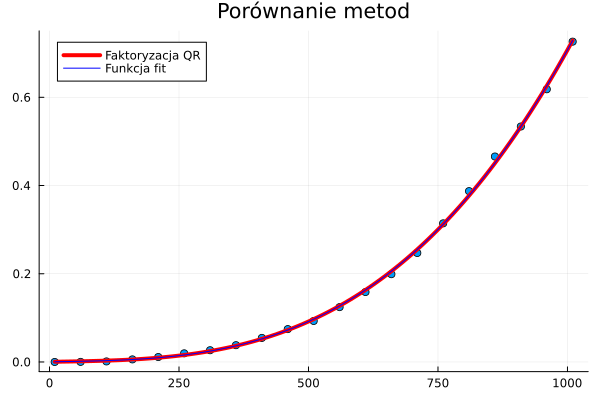

In [13]:
scatter(x_julia, y_julia_i, label ="")
plot!(poly_aprox,  
    extrema(x_julia)..., 
    label = "Faktoryzacja QR",
    color = :red,
    linewidth = 4,
    title = "Porównanie metod"
)
plot!(fit_aprox,  
    extrema(x_julia)..., 
    label = "Funkcja fit",
    color = :blue
)

# Zadanie 3 - Zastosowanie faktoryzacji (Pseudoinwersja macierzy z wykorzystaniem SVD)

### Funkcja: `pseudoinverse(A)`

Oblicza **pseudoodwrotność** macierzy `A` (czyli odwrotność w sensie najmniejszych kwadratów, tzw. odwrotność Moore’a-Penrose’a) przy użyciu rozkładu SVD.

#### Działanie:

1. Oblicza rozkład SVD:

   ```julia
   U, S, V = svd(A)
   ```

   * `U` – macierz unitarna `m x m` (lewe wektory osobliwe)
   * `S` – wektor wartości osobliwych (o długości `min(m, n)`), (w matematyce: Macierz Diagonalna)
   * `V` – macierz unitarna `n x n` (prawe wektory osobliwe)

2. Ustala tolerancję do odrzucania bardzo małych (bliskich zeru) wartości osobliwych:

   ```julia
   tolerance = maximum(size(A)) * eps(real(eltype(S))) * maximum(S)
   ```

3. Oblicza odwrotność wartości osobliwych (tylko tych większych niż tolerancja), tworząc macierz diagonalną `Sinv`:

   ```julia
   Sinv = Diagonal([s > tol ? 1/s : zero(s) for s in S])
   ```

4. Zwraca pseudoodwrotność:

   ```julia
   V * Sinv * U'
   ```

   * `U'` – transpozycja sprzężona macierzy `U` (w Julii: Hermitowskie transponowanie)


In [14]:
function pseudoinverse(A)
    U, S, V = svd(A)
    tolerance = maximum(size(A)) * eps(real(eltype(S))) * maximum(S)
    Sinv = Diagonal([s > tolerance ? 1/s : zero(s) for s in S])
    return V * Sinv * U'
end

pseudoinverse (generic function with 1 method)

In [15]:
A = [
    1  0;
    0  1;
    sqrt(3)  0
]

pseudoinverse(A)

2×3 Matrix{Float64}:
 0.25  0.0  0.433013
 0.0   1.0  0.0

#### Porównanie odwrotności macierzy kwadratowej z funkcją standardową

In [16]:
A = rand(100, 100)

pinv_A = pseudoinverse(A)
inv_A = inv(A)

println("Pseudoodwrotność:\n")
display(pinv_A)
println("Standardowa odwrotność:\n")
display(inv_A)

println("Są zbliżone? ", isapprox(pinv_A, inv_A))

Pseudoodwrotność:



100×100 Matrix{Float64}:
 -0.0804567   -0.0652191    0.0990142   0.303042   …  -0.0447553   0.0298202
  0.0989404    0.802398    -1.22854    -0.84033        0.978484    1.66616
 -0.160498     0.526082    -0.666989   -0.706257       0.531844    0.839807
  0.120361    -0.0116944   -0.327589    0.386139       0.237075    0.492737
  0.127366     0.207784    -0.235163   -1.11972        0.136666    0.338191
  0.0872513    0.654839    -0.689988   -0.849169   …   0.421418    0.853742
 -0.418522    -1.08553      1.61766     1.15595       -1.20731    -2.25518
 -0.129855    -0.648933     0.776414    1.02847       -0.660949   -1.35035
  0.633847     1.79444     -2.28958    -1.37768        1.57202     3.2274
  0.0353728   -0.165569     0.146843   -0.431548      -0.208604   -0.272649
  0.2579       0.523543    -0.635497    0.0575816  …   0.3302      0.699528
 -0.263102    -0.3111       0.37924    -0.346582      -0.35202    -0.842772
  0.103787     0.214702    -0.41317    -0.268504       0.344359    

Standardowa odwrotność:



100×100 Matrix{Float64}:
 -0.0804567   -0.0652191    0.0990142   0.303042   …  -0.0447553   0.0298202
  0.0989404    0.802398    -1.22854    -0.84033        0.978484    1.66616
 -0.160498     0.526082    -0.666989   -0.706257       0.531844    0.839807
  0.120361    -0.0116944   -0.327589    0.386139       0.237075    0.492737
  0.127366     0.207784    -0.235163   -1.11972        0.136666    0.338191
  0.0872513    0.654839    -0.689988   -0.849169   …   0.421418    0.853742
 -0.418522    -1.08553      1.61766     1.15595       -1.20731    -2.25518
 -0.129855    -0.648933     0.776414    1.02847       -0.660949   -1.35035
  0.633847     1.79444     -2.28958    -1.37768        1.57202     3.2274
  0.0353728   -0.165569     0.146843   -0.431548      -0.208604   -0.272649
  0.2579       0.523543    -0.635497    0.0575816  …   0.3302      0.699528
 -0.263102    -0.3111       0.37924    -0.346582      -0.35202    -0.842772
  0.103787     0.214702    -0.41317    -0.268504       0.344359    

Są zbliżone? true


In [17]:
A = rand(100, 40)

pinv_A = pseudoinverse(A)

println("Pseudoodwrotność:\n")
display(pinv_A)

Pseudoodwrotność:



40×100 Matrix{Float64}:
 -0.0400338   -0.0998598    0.00251996   …  -0.0658706     0.0579931
 -0.0275237   -0.0160872    0.0224454       -0.000485841  -0.0781786
 -0.0281991   -0.0871912    0.0512641       -0.0324029     0.0214548
  0.0831517   -0.0579788    0.0263995        0.065144      0.0113066
 -0.0596008    0.103118    -0.0233769       -0.0746248     0.0430923
  0.0541652    0.0408897   -0.00327697   …   0.056139      0.0950382
  0.0265217    0.0934036   -0.0807861        0.0409098    -0.00609218
  0.0698466   -0.034786     0.0156855       -0.0329478     0.0114851
 -0.0150824   -0.0106065   -0.0249973        0.00708908   -0.00765985
 -5.082e-5     0.0475633   -0.029775         0.0154826    -0.0642561
 -0.03268     -0.021056     0.0585497    …   0.011251      0.0481696
  0.0633368    0.0515358    0.00499015      -0.0591167     0.0137413
  0.0566868    0.00911814   0.032558         0.020565      0.0623257
  ⋮                                      ⋱                
  0.0213004    0.0

In [18]:
A = rand(100, 1)

pinv_A = pseudoinverse(A)

println("Pseudoodwrotność:\n")
display(pinv_A)

Pseudoodwrotność:



1×100 Matrix{Float64}:
 0.0140666  0.00148216  0.000494574  …  0.0225992  0.015811  0.0262137